*Importing the libraries and setting the AI-friendly export settings:*

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   # embed TrueType fonts, keep text editable
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans'] 

*Reading the main dataframe with clinical metadata and flow cytometry parameters:*

In [ ]:
# upper day limit for horizoning the clinical follow-up
cutoff = 2000

print('reading the main dataframe:')
# path to the full dataset excel with clinical metadata and flow cytometry parameters for the patients:
full_dataset_clinmetadata_flowcytometrydata_path = ''d35_input_full_copy = d35_input_full[(d35_input_full['OC_d35_PassCrit_FCAnalysis'] == 'Yes') | (d35_input_full['VC_d35_PassCrit_FCAnalysis'] == 'Yes')]
d35_input_full_copy = d35_input_full[(d35_input_full['OC_d35_PassCrit_FCAnalysis'] == 'Yes') | (d35_input_full['VC_d35_PassCrit_FCAnalysis'] == 'Yes')]

PERCENT_FEATURES = [c for c in d35_input_full_copy.columns if ' of ' in c]
myeloid_endings = [' of DC/HLA-DRpos_APC',' of Monocytes',' of Myeloid']
myeloid_endings_and_CD45pos = [' of DC/HLA-DRpos_APC',' of Monocytes',' of Myeloid', ' of CD45pos']
myeloid_child = set(element.split(' of ')[0] for element in PERCENT_FEATURES if element.endswith(tuple(myeloid_endings)))
myeloid_params_exclude = [element for element in PERCENT_FEATURES if element.startswith(tuple(myeloid_child)) and element.endswith(tuple(myeloid_endings_and_CD45pos))]
PERCENT_FEATURES = list(set(PERCENT_FEATURES) - set(myeloid_params_exclude))

PERCENT_FEATURES_renamer = {}
to_rename = [element for element in PERCENT_FEATURES if 'LowLevel' in element]
for element in to_rename:
    PERCENT_FEATURES_renamer[element] = element.replace('LowLevel ', 'High Resolution ')
d35_input_full_copy = d35_input_full_copy.rename(columns = PERCENT_FEATURES_renamer)
PERCENT_FEATURES = [element.replace('LowLevel ', 'High Resolution ') for element in PERCENT_FEATURES]

RATIO_FEATURES   = [c for c in d35_input_full_copy.columns if '-to-' in c]
OUTCOME_COLS = {
    "RFS": {"time": 'Time_to_Relapse_from_TPL', "event": 'Relapse_Present_1_NotObserved_0'},
    "OS":  {"time": 'Time_to_Death_from_TPL',  "event": 'Death_Present_1_NotObserved_0'},
    "aGVHD": {"time": "Time_to_aGVHD", "event": "aGVHD_grading_by_Katja"},
    "cGVHD": {"time": "Time_to_cGVHD", "event": "cGVHD_grading_by_Katja"},
}

d35_input_full_copy[OUTCOME_COLS['RFS']['event']] = np.where(d35_input_full_copy[OUTCOME_COLS['RFS']['time']] >= cutoff, 0, d35_input_full_copy[OUTCOME_COLS['RFS']['event']])
d35_input_full_copy[OUTCOME_COLS['RFS']['time']] = np.where(d35_input_full_copy[OUTCOME_COLS['RFS']['time']] >= cutoff, cutoff, d35_input_full_copy[OUTCOME_COLS['RFS']['time']])

d35_input_full_copy[OUTCOME_COLS['OS']['event']] = np.where(d35_input_full_copy[OUTCOME_COLS['OS']['time']] >= cutoff, 0, d35_input_full_copy[OUTCOME_COLS['OS']['event']])
d35_input_full_copy[OUTCOME_COLS['OS']['time']] = np.where(d35_input_full_copy[OUTCOME_COLS['OS']['time']] >= cutoff, cutoff, d35_input_full_copy[OUTCOME_COLS['OS']['time']])

d35_input_full_copy[OUTCOME_COLS['aGVHD']['event']] = np.where(d35_input_full_copy[OUTCOME_COLS['aGVHD']['time']] >= cutoff, 0, d35_input_full_copy[OUTCOME_COLS['aGVHD']['event']])
d35_input_full_copy[OUTCOME_COLS['aGVHD']['time']] = np.where(d35_input_full_copy[OUTCOME_COLS['aGVHD']['time']] >= cutoff, cutoff, d35_input_full_copy[OUTCOME_COLS['aGVHD']['time']])

d35_input_full_copy[OUTCOME_COLS['cGVHD']['event']] = np.where(d35_input_full_copy[OUTCOME_COLS['cGVHD']['time']] >= cutoff, 0, d35_input_full_copy[OUTCOME_COLS['cGVHD']['event']])
d35_input_full_copy[OUTCOME_COLS['cGVHD']['time']] = np.where(d35_input_full_copy[OUTCOME_COLS['cGVHD']['time']] >= cutoff, cutoff, d35_input_full_copy[OUTCOME_COLS['cGVHD']['time']])


d35_input_full_copy['Relapse_Present_1_NotObserved_0'] = d35_input_full_copy['Relapse_Present_1_NotObserved_0'].astype("Int64")
d35_input_full_copy['aGVHD_grading_by_Katja'] = d35_input_full_copy['aGVHD_grading_by_Katja'].astype("Int64")
d35_input_full_copy['cGVHD_grading_by_Katja'] = d35_input_full_copy['cGVHD_grading_by_Katja'].astype("Int64")
d35_input_full_copy['FC_Sampling_Days_After_Allo_d35'] = round(d35_input_full_copy['FC_Sampling_Days_After_Allo_d35'], 0)
d35_input_full_copy['FC_Sampling_Days_After_Allo_d35'] = d35_input_full_copy['FC_Sampling_Days_After_Allo_d35'].astype("Int64")
d35_input_full_copy['MAX_FOLLOW_UP'] = d35_input_full_copy[['Time_to_aGVHD', 'Time_to_cGVHD',
                                                            'Time_to_Relapse_from_TPL','Time_to_Death_from_TPL']].max(axis = 1)

d35_input_full_copy['Time_to_Death_from_TPL'] -= d35_input_full_copy['FC_Sampling_Days_After_Allo_d35']
d35_input_full_copy['Time_to_Relapse_from_TPL'] -= d35_input_full_copy['FC_Sampling_Days_After_Allo_d35']
d35_input_full_copy['Time_to_aGVHD'] -= d35_input_full_copy['FC_Sampling_Days_After_Allo_d35']
# only 65 patients (40 in VC and 25 in OC)
d35_input_full_copy['Time_to_cGVHD'] -= d35_input_full_copy['FC_Sampling_Days_After_Allo_d35']
d35_input_full_copy['MAX_FOLLOW_UP'] -= d35_input_full_copy['FC_Sampling_Days_After_Allo_d35']

reading the main dataframe:


*Reshaping metadata columns:*

In [6]:
df_multivariate = d35_input_full_copy.copy()
age_cutoff = 60
df_multivariate[f'Age(>{age_cutoff})'] = np.where(df_multivariate['Age'] > age_cutoff, 1, 0)
df_multivariate['MHC_Mismatch_between_Donor&Recipient'] = np.where(df_multivariate['MHC_Mismatch_between_Donor&Recipient'] == 'nein', 'Match', 'Mismatch')
df_multivariate['MHC_Mismatch_Numeric'] = np.where(df_multivariate['HLA_Category_refined'] != '10/10', 'Mismatch', '10/10')
df_multivariate['ELN_Score(3)'] = np.where(df_multivariate['ELN_Score'] == 3, 1, 0)
d35_input_full_copy['Sex_Recipient(M=1)'] = np.where(d35_input_full_copy['Sex_Recipient'] == 'Male', 1, 0) # Male = 0, Female = 1

df_multivariate['Disease_Score(2)'] = np.where(df_multivariate['Disease_Score'] == 2, 1, 0)
df_multivariate['CMV_Status_Recipient(+)'] = np.where(df_multivariate['CMV_Status_Recipient'] == 'neg', '-', '+')
df_multivariate['CMV_Status(R/D)'] = df_multivariate['CMV_Status_Recipient'] + '_' + df_multivariate['CMV_Status_Donor']
df_multivariate['CMV_Status(R/D)'] = df_multivariate['CMV_Status(R/D)'].replace({
    'pos_pos': '+/+',
    'neg_neg': 'Other',
    'pos_neg': 'Other',
    'neg_pos': 'Other',
})

*Calculating the ICC35 score:*

In [7]:
parameters = {
    # 'High Resolution CD8 CCR7- CD45RAmid CD27+ CD57+ GPR56+ of CD45pos': 'GvL_Score',
    'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': 'GvL_Score',
    
    # 'High Resolution CD56dim NK CD45RA+ CD57+ CD8+ GPR56+ of Lymphocytes': 'GvHD_Score',
    'CD4 CCR7mid CD45RA- of T': 'GvHD_Score',
    'CD4_Naive+CD4_TCM-to-CD4_rest': 'GvHD_Score'
}

direction = {
    # 'High Resolution CD8 CCR7- CD45RAmid CD27+ CD57+ GPR56+ of CD45pos': 'protective',
    'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': 'protective',
    
    # 'High Resolution CD56dim NK CD45RA+ CD57+ CD8+ GPR56+ of Lymphocytes': 'protective',
    'CD4 CCR7mid CD45RA- of T': 'non-protective',
    'CD4_Naive+CD4_TCM-to-CD4_rest': 'non-protective'
}

def sign_intepreter(parameter):
    if direction[parameter] == 'protective':
        return [1,0]
    else:
        return [0,1]

cutoffs = {}
for parameter in list(parameters.keys()):
    cutoffs[parameter] = {
        'OC': np.median(df_multivariate[df_multivariate['Cohort'] == 'OC'][parameter]),
        'VC': np.median(df_multivariate[df_multivariate['Cohort'] == 'VC'][parameter])
    }

for parameter in cutoffs:
    df_multivariate[f'{parameter}_SCORE'] = np.where(df_multivariate['Cohort'] == 'OC',
                                                     np.where(df_multivariate[parameter] > cutoffs[parameter]['OC'], sign_intepreter(parameter)[0], sign_intepreter(parameter)[1]),
                                                     np.where(df_multivariate[parameter] > cutoffs[parameter]['VC'], sign_intepreter(parameter)[0], sign_intepreter(parameter)[1])
                                                    )
GvL_params = list({k:v for k,v in parameters.items() if v == 'GvL_Score'}.keys())
GvHD_params = list({k:v for k,v in parameters.items() if v == 'GvHD_Score'}.keys())
df_multivariate['GvL_Score'] = df_multivariate[[f'{element}_SCORE' for element in GvL_params]].sum(axis = 1)
df_multivariate['GvHD_Score'] = df_multivariate[[f'{element}_SCORE' for element in GvHD_params]].sum(axis = 1)
df_multivariate['GvLhi_GvHDlo'] = np.where((df_multivariate['GvL_Score'] == len({k:v for k,v in parameters.items() if v == 'GvL_Score'})) & 
                                         (df_multivariate['GvHD_Score'] == len({k:v for k,v in parameters.items() if v == 'GvHD_Score'})), 1, 0)

*Inroducting piechart plotting functions:*

In [8]:
def make_autopct(values):
    def autopct(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))

        if count == 0:
            return ''

        return f'{count}\n({pct:.1f}%)'
        # return f'{count}'

    return autopct
def plot_gvhd_pies(
    count_df,
    cohort_col="Cohort",
    score_col="FinalScore",
    grade_col="",
    count_col="count",
    cohort_order=("OC", "VC"),
    score_order=("good", "bad"),
    grade_order=None,
    legend_title = "",
    fontsize_selected = 12,
    colors_set = None,
    save_path=None,
    highlight_grades=None,
    highlight_edgecolor="black",
    highlight_linewidth=2.5,
    highlight_explode=0.2,
):
    if grade_order is None:
        grade_order = sorted(count_df[grade_col].dropna().unique())

    fig, axes = plt.subplots(
        len(cohort_order),
        len(score_order),
        figsize=(len(score_order) * 2.5, len(cohort_order) * 2.5)
    )

    for i, cohort in enumerate(cohort_order):
        for j, score in enumerate(score_order):
            ax = axes[i, j]

            sub = count_df[
                (count_df[cohort_col] == cohort) &
                (count_df[score_col] == score)
            ]

            sub = (
                sub.set_index(grade_col)
                .reindex(grade_order)
                .reset_index()
            )

            sub[count_col] = sub[count_col].fillna(0).astype(int)
            sub[cohort_col] = cohort
            sub[score_col] = score

            values = sub[count_col].values
            labels = sub[grade_col].astype(str).values

            if highlight_grades is None:
                highlight_grades = []

            explode = [
                highlight_explode if grade in highlight_grades else 0
                for grade in labels
            ]

            wedges, _, autotexts = ax.pie(
                values,
                labels=None,
                autopct=make_autopct(values),
                startangle=90,
                pctdistance=0.73,
                textprops={"fontsize": fontsize_selected},
                colors = colors_set,
                explode=explode,
                wedgeprops={"linewidth": 0.4, "edgecolor": "white"}
            )

            for wedge, grade in zip(wedges, labels):
                if grade in highlight_grades:
                    wedge.set_edgecolor(highlight_edgecolor)
                    wedge.set_linewidth(highlight_linewidth)

            # for autotext in autotexts:
            #     autotext.set_bbox(
            #         dict(facecolor="white", edgecolor="black",
            #              boxstyle="round,pad=0.25")
            #     )

            ax.axis("equal")

            if i == 0:
                ax.set_title(score, fontsize=fontsize_selected)

            if j == 0:
                ax.set_ylabel(cohort, fontsize=fontsize_selected)

    # one shared legend
    fig.legend(
        wedges,
        labels,
        title=legend_title,
        loc="center right",
        bbox_to_anchor = ((1.4, 0.5) if grade_col in ['no_cGVHD12_no_aGVHD34', 'no_cGVHD2_no_aGVHD34']else (1.05, 0.5)),
        frameon=True,
        fontsize = fontsize_selected,
        title_fontsize=fontsize_selected,
        framealpha=1
    )

    plt.subplots_adjust(wspace=0, hspace=0)
    plt.tight_layout(rect=[0, 0, 0.9, 1])
    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")

    plt.show()

<br></br>
*PieCharts for IC35 vs ELN categories:*

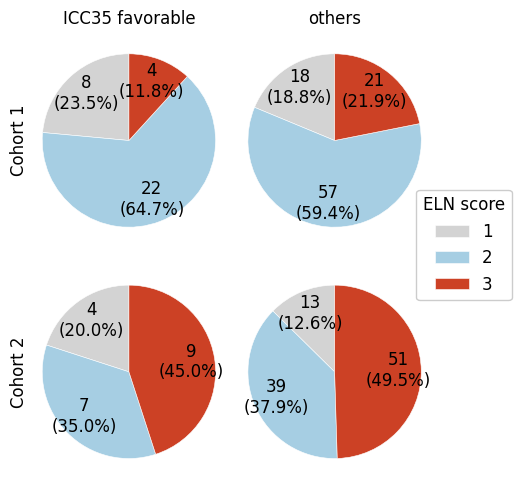

In [ ]:
df_multivariate_copy = df_multivariate.copy()
df_multivariate_copy['Cohort'] = df_multivariate_copy['Cohort'].replace({'OC': 'Cohort 1', 'VC': 'Cohort 2'})
df_multivariate_copy['GvLhi_GvHDlo'] = df_multivariate_copy['GvLhi_GvHDlo'].replace({0: 'others', 1: 'ICC35 favorable'})
GVHD_FinalScore_Output = pd.DataFrame(df_multivariate_copy[['Cohort', 'GvLhi_GvHDlo', 'ELN_Score']].value_counts()).reset_index().sort_values(by = ['Cohort', 'GvLhi_GvHDlo', 'ELN_Score'])

colors_set = [
    "#D3D3D3",  # grade 0
    "#A6CEE3",  # grade 1
    # "#E9A6A6",  # grade 2
    "#CC4125",  # grade 3
    # "#8E7CC3"   # grade 4
]

# colors_set = [
#     "#A6CEE3",  # grade 0-2
#     "#CC4125",  # grade 3-4
# ]

# specify the pichart output directory:
save_dir = ''
plot_gvhd_pies(
    count_df=GVHD_FinalScore_Output,
    cohort_col="Cohort",
    score_col="GvLhi_GvHDlo",
    grade_col="ELN_Score",
    count_col="count",
    cohort_order=["Cohort 1", "Cohort 2"],
    score_order=['ICC35 favorable', 'others'],
    # grade_order=[0, 1, 2, 3, 4],
    grade_order=[1,2,3],
    legend_title = "ELN score",
    fontsize_selected = 12,
    colors_set=colors_set,
    # save_path=f'{save_dir}/aGVHD_grades_GvL_GvHD_score_piecharts.pdf'
    save_path=f'{save_dir}/ELNcats_GvL_GvHD_score_piecharts_vPercNoBoxes.pdf',
    highlight_grades=None
)

<br></br>
*Pie charts for ICC35 score vs aGVHD categories:*

In [ ]:
df_multivariate_copy = df_multivariate.copy()
df_multivariate_copy = df_multivariate_copy[~((df_multivariate_copy['aGVHD_grading_by_Katja'] != 0) & (df_multivariate_copy['Time_to_aGVHD'] <= 0))]
df_multivariate_copy['aGVHD_grading_by_Katja'] = np.where(df_multivariate_copy['aGVHD_grading_by_Katja'].isin([0,1,2]), '0-2', '3-4')
GVHD_FinalScore_Output = pd.DataFrame(df_multivariate_copy[['Cohort', 'GvLhi_GvHDlo', 'aGVHD_grading_by_Katja']].value_counts()).reset_index().sort_values(by = ['Cohort', 'GvLhi_GvHDlo', 'aGVHD_grading_by_Katja'])
GVHD_FinalScore_Output['Cohort'] = GVHD_FinalScore_Output['Cohort'].replace({'OC': 'Cohort 1', 'VC': 'Cohort 2'})
GVHD_FinalScore_Output['GvLhi_GvHDlo'] = GVHD_FinalScore_Output['GvLhi_GvHDlo'].replace({0: 'others', 1: 'ICC35 favorable'})

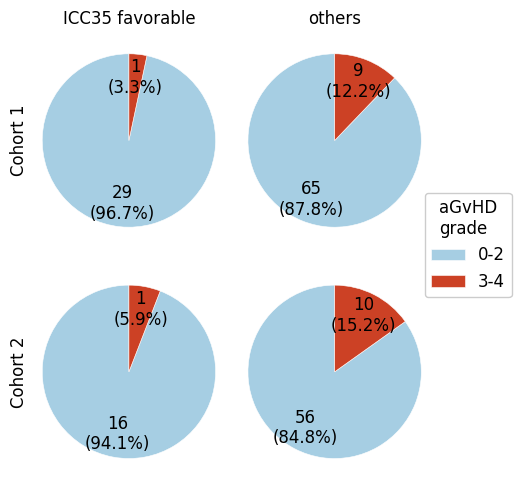

In [ ]:
# colors_set = [
#     "#D3D3D3",  # grade 0
#     "#A6CEE3",  # grade 1
#     "#E9A6A6",  # grade 2
#     "#CC4125",  # grade 3
#     "#8E7CC3"   # grade 4
# ]

colors_set = [
    "#A6CEE3",  # grade 0-2
    "#CC4125",  # grade 3-4
]

# specify the pichart output directory:
save_dir = ''
plot_gvhd_pies(
    count_df=GVHD_FinalScore_Output,
    cohort_col="Cohort",
    score_col="GvLhi_GvHDlo",
    grade_col="aGVHD_grading_by_Katja",
    count_col="count",
    cohort_order=["Cohort 1", "Cohort 2"],
    score_order=['ICC35 favorable', 'others'],
    # grade_order=[0, 1, 2, 3, 4],
    grade_order=["0-2", "3-4"],
    legend_title = "aGvHD\ngrade",
    fontsize_selected = 12,
    colors_set=colors_set,
    # save_path=f'{save_dir}/aGVHD_grades_GvL_GvHD_score_piecharts.pdf'
    save_path=f'{save_dir}/aGVHD_grades_GvL_GvHD_score_piecharts_012_34_grouped_vPercNoBoxes.pdf',
    highlight_grades=None
)

<br></br>
*Pie charts for ICC35 score vs cGVHD categories:*

In [20]:
df_multivariate_copy = df_multivariate.copy()
# df_multivariate_copy['cGVHD_grading_by_Katja'] = np.where(df_multivariate_copy['cGVHD_grading_by_Katja'].isin([0,1]), '0-1', '2')

GVHD_FinalScore_Output = pd.DataFrame(df_multivariate_copy[['Cohort', 'GvLhi_GvHDlo', 'cGVHD_grading_by_Katja']].value_counts()).reset_index().sort_values(by = ['Cohort', 'GvLhi_GvHDlo', 'cGVHD_grading_by_Katja'])
GVHD_FinalScore_Output['Cohort'] = GVHD_FinalScore_Output['Cohort'].replace({'OC': 'Cohort 1', 'VC': 'Cohort 2'})
GVHD_FinalScore_Output['GvLhi_GvHDlo'] = GVHD_FinalScore_Output['GvLhi_GvHDlo'].replace({0: 'others', 1: 'ICC35 favorable'})

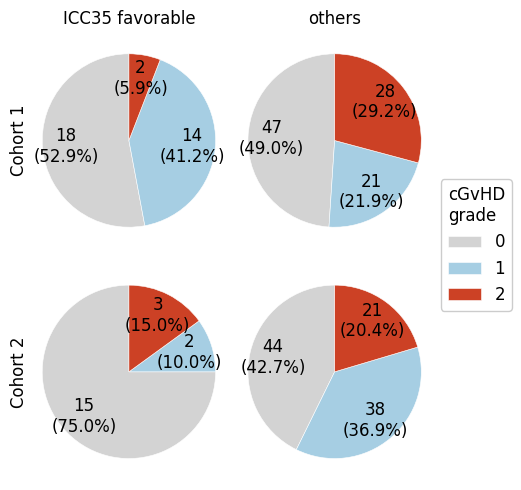

In [ ]:
colors_set = [
    "#D3D3D3",  # grade 0
    "#A6CEE3",  # grade 1
    "#CC4125",  # grade 2
]

# colors_set = [
#     "#A6CEE3",  # grade 0-1
#     "#CC4125",  # grade 2
# ]

# specify the pichart output directory:
save_dir = ''
plot_gvhd_pies(
    count_df=GVHD_FinalScore_Output,
    cohort_col="Cohort",
    score_col="GvLhi_GvHDlo",
    grade_col="cGVHD_grading_by_Katja",
    count_col="count",
    cohort_order=["Cohort 1", "Cohort 2"],
    score_order=['ICC35 favorable', 'others'],
    grade_order=[0, 1, 2],
    # grade_order=["0-1", "2"],
    legend_title = "cGvHD\ngrade",
    fontsize_selected = 12,
    colors_set=colors_set,
    save_path=f'{save_dir}/cGVHD_grades_GvL_GvHD_score_piecharts_vPercNoBoxes.pdf'
    # save_path=f'{save_dir}/cGVHD_grades_GvL_GvHD_score_piecharts_01_2_grouped_vPercNoBoxes.pdf'
)

<br></br>
*Pie charts for CD56dim NK (tertiles / medians) vs aGVHD/cGVHD categories:*

In [12]:
NK_split = 3
if NK_split == 2:
    NK_split_name = 'Medians'
    NK_labels = ["CD56dim NK lo", "CD56dim NK hi"]
elif NK_split == 3:
    NK_split_name = 'Tertiles'
    NK_labels = ["CD56dim NK lo", "CD56dim NK mid", "CD56dim NK hi"]

NK_parameter = 'HighRes'
# 'HighRes' / 'General'

In [13]:
df_multivariate_copy = df_multivariate.copy()
if NK_parameter == 'HighRes':
  df_multivariate_copy['CD56dimNK++_split'] = (
      df_multivariate_copy.groupby("Cohort")['High Resolution CD56dim NK CD45RA+ CD57+ GPR56+ of Lymphocytes']
        .transform(lambda x: pd.qcut(x, q=NK_split, labels=NK_labels))
  )
else:
  df_multivariate_copy['CD56dimNK++_split'] = (
      df_multivariate_copy.groupby("Cohort")["CD56dim NK CD57+ GPR56+ of Lymphocytes"]
        .transform(lambda x: pd.qcut(x, q=NK_split, labels=NK_labels))
  )


*Pie charts for CD56dim NK (tertiles / medians) vs aGVHD categories:*

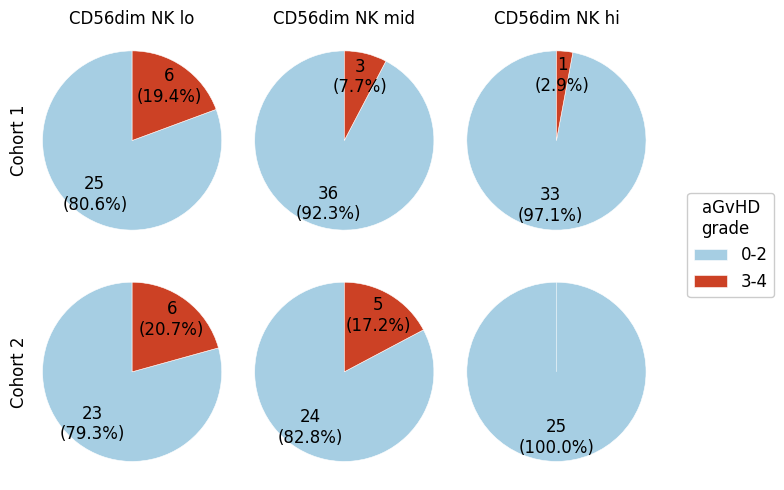

In [ ]:
# aGVHD: 0-2 vs 3-4
colors_set = [
    # "#D3D3D3",  # grade 0
    "#A6CEE3",  # grade 0-2
    "#CC4125",  # grade 3-4
]
col_of_interest = 'aGVHD_merged'
df_multivariate_copy = df_multivariate_copy[~((df_multivariate_copy['aGVHD_grading_by_Katja'] != 0) & (df_multivariate_copy['Time_to_aGVHD'] <= 0))]
df_multivariate_copy['aGVHD_merged'] = np.where(df_multivariate_copy['aGVHD_grading_by_Katja'].isin([0,1,2]), '0-2', '3-4')

GVHD_FinalScore_Output = pd.DataFrame(df_multivariate_copy[['Cohort', 'CD56dimNK++_split', col_of_interest]].value_counts()).reset_index().sort_values(by = ['Cohort', 'CD56dimNK++_split', col_of_interest])
GVHD_FinalScore_Output['Cohort'] = GVHD_FinalScore_Output['Cohort'].replace({'OC': 'Cohort 1', 'VC': 'Cohort 2'})

# specify the pichart output directory:
save_dir = ''
plot_gvhd_pies(
    count_df=GVHD_FinalScore_Output,
    cohort_col="Cohort",
    score_col='CD56dimNK++_split',
    grade_col=col_of_interest,
    count_col="count",
    cohort_order=["Cohort 1", "Cohort 2"],
    score_order=NK_labels,
    grade_order=["0-2", "3-4"],
    legend_title = "aGvHD\ngrade",
    fontsize_selected = 12,
    colors_set=colors_set,
    save_path=f'{save_dir}/aGVHD_grades_012_34_{NK_parameter}NKdim{NK_split_name}_piecharts_vPercNoBoxes.pdf'
)

*Pie charts for CD56dim NK (tertiles / medians) vs cGVHD categories:*

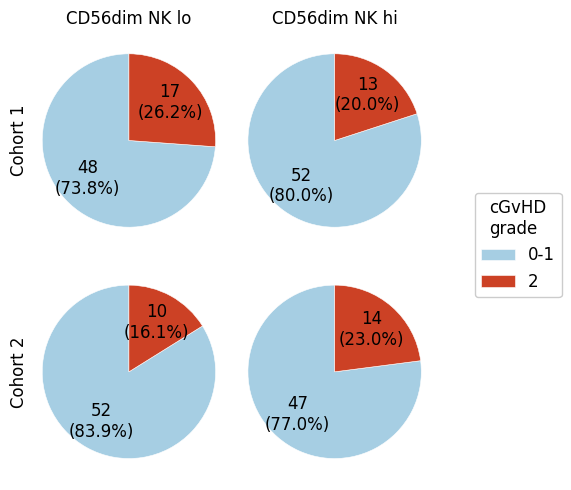

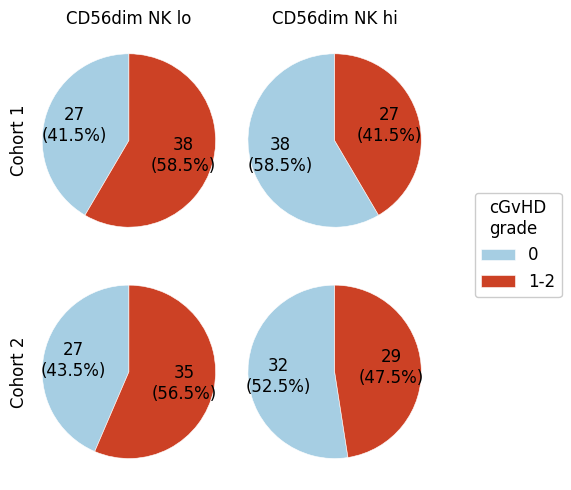

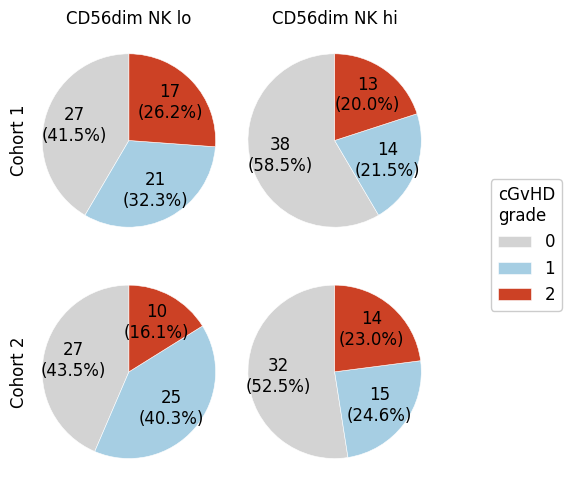

In [ ]:
# cGVHD: 0 1 2
colors_set = [
    # "#D3D3D3",  # grade 0
    "#A6CEE3",  # grade 0-2
    "#CC4125",  # grade 3-4
]
col_of_interest = 'cGVHD_merged_01_2'
df_multivariate_copy['cGVHD_merged_01_2'] = np.where(df_multivariate_copy['cGVHD_grading_by_Katja'].isin([0,1]), '0-1', '2')
GVHD_FinalScore_Output = pd.DataFrame(df_multivariate_copy[['Cohort', 'CD56dimNK++_split', col_of_interest]].value_counts()).reset_index().sort_values(by = ['Cohort', 'CD56dimNK++_split', col_of_interest])
GVHD_FinalScore_Output['Cohort'] = GVHD_FinalScore_Output['Cohort'].replace({'OC': 'Cohort 1', 'VC': 'Cohort 2'})

# specify the pichart output directory:
save_dir = ''
plot_gvhd_pies(
    count_df=GVHD_FinalScore_Output,
    cohort_col="Cohort",
    score_col='CD56dimNK++_split',
    grade_col=col_of_interest,
    count_col="count",
    cohort_order=["Cohort 1", "Cohort 2"],
    score_order=NK_labels,
    grade_order=["0-1", "2"],
    legend_title = "cGvHD\ngrade",
    fontsize_selected = 12,
    colors_set=colors_set,
    save_path=f'{save_dir}/cGVHD_grades_01_2_{NK_parameter}NKdim{NK_split_name}_piecharts_vPercNoBoxes.pdf'
)



col_of_interest = 'cGVHD_merged_0_12'
df_multivariate_copy['cGVHD_merged_0_12'] = np.where(df_multivariate_copy['cGVHD_grading_by_Katja'].isin([0]), '0', '1-2')
GVHD_FinalScore_Output = pd.DataFrame(df_multivariate_copy[['Cohort', 'CD56dimNK++_split', col_of_interest]].value_counts()).reset_index().sort_values(by = ['Cohort', 'CD56dimNK++_split', col_of_interest])
GVHD_FinalScore_Output['Cohort'] = GVHD_FinalScore_Output['Cohort'].replace({'OC': 'Cohort 1', 'VC': 'Cohort 2'})

# specify the pichart output directory:
save_dir = ''
plot_gvhd_pies(
    count_df=GVHD_FinalScore_Output,
    cohort_col="Cohort",
    score_col='CD56dimNK++_split',
    grade_col=col_of_interest,
    count_col="count",
    cohort_order=["Cohort 1", "Cohort 2"],
    score_order=NK_labels,
    grade_order=["0", "1-2"],
    legend_title = "cGvHD\ngrade",
    fontsize_selected = 12,
    colors_set=colors_set,
    save_path=f'{save_dir}/cGVHD_grades_0_12_{NK_parameter}NKdim{NK_split_name}_piecharts_vPercNoBoxes.pdf'
)



colors_set = [
    "#D3D3D3",  # grade 0
    "#A6CEE3",  # grade 0-2
    "#CC4125",  # grade 3-4
]
col_of_interest = 'cGVHD_grading_by_Katja'
GVHD_FinalScore_Output = pd.DataFrame(df_multivariate_copy[['Cohort', 'CD56dimNK++_split', col_of_interest]].value_counts()).reset_index().sort_values(by = ['Cohort', 'CD56dimNK++_split', col_of_interest])
GVHD_FinalScore_Output['Cohort'] = GVHD_FinalScore_Output['Cohort'].replace({'OC': 'Cohort 1', 'VC': 'Cohort 2'})

# specify the pichart output directory:
save_dir = ''
plot_gvhd_pies(
    count_df=GVHD_FinalScore_Output,
    cohort_col="Cohort",
    score_col='CD56dimNK++_split',
    grade_col=col_of_interest,
    count_col="count",
    cohort_order=["Cohort 1", "Cohort 2"],
    score_order=NK_labels,
    grade_order=[0,1,2],
    legend_title = "cGvHD\ngrade",
    fontsize_selected = 12,
    colors_set=colors_set,
    save_path=f'{save_dir}/cGVHD_grades_0_1_2_{NK_parameter}NKdim{NK_split_name}_piecharts_vPercNoBoxes.pdf'
)

*Pie charts for CD56dim NK (tertiles / medians) vs aGVHD/cGVHD categories combined:*

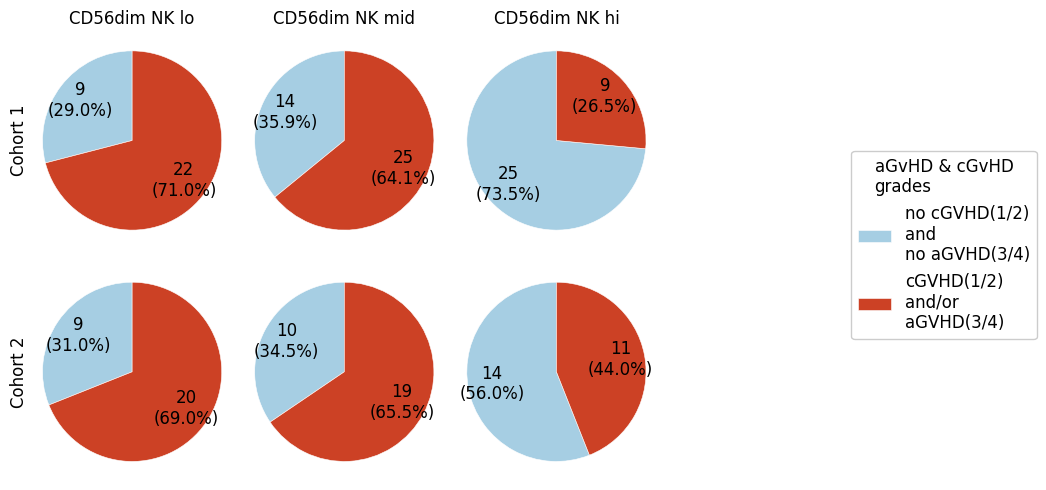

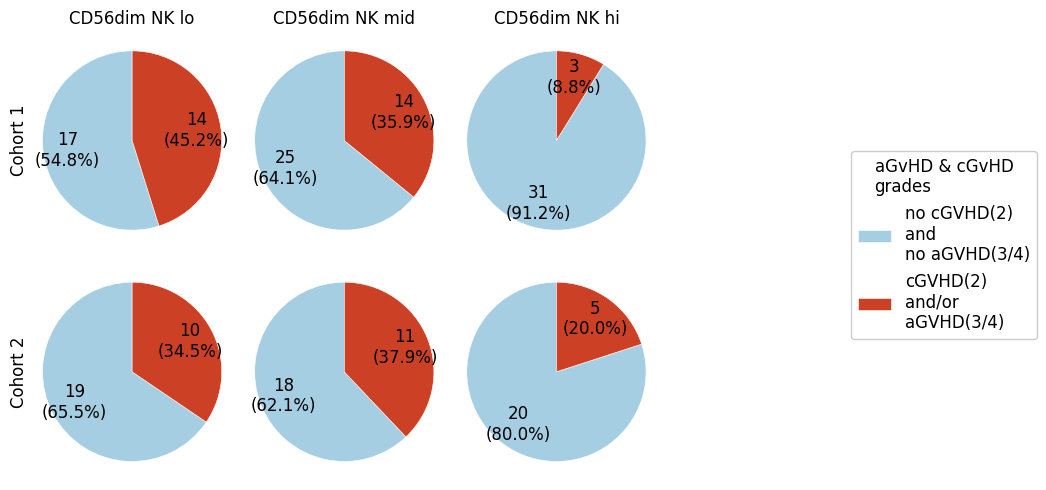

In [ ]:
# aGVHD and cGVHD together:
colors_set = [
    # "#D3D3D3",  # grade 0
    "#A6CEE3",  # grade 0-2
    "#CC4125",  # grade 3-4
]
col_of_interest = 'no_cGVHD12_no_aGVHD34'
df_multivariate_copy = df_multivariate_copy[~((df_multivariate_copy['aGVHD_grading_by_Katja'] != 0) & (df_multivariate_copy['Time_to_aGVHD'] <= 0))]
df_multivariate_copy['no_cGVHD12_no_aGVHD34'] = np.where((~df_multivariate_copy['cGVHD_grading_by_Katja'].isin([1,2])) & (~df_multivariate_copy['aGVHD_grading_by_Katja'].isin([3,4])), f'no cGVHD(1/2)\nand\nno aGVHD(3/4)', f'cGVHD(1/2)\nand/or\naGVHD(3/4)')
GVHD_FinalScore_Output = pd.DataFrame(df_multivariate_copy[['Cohort', 'CD56dimNK++_split', col_of_interest]].value_counts()).reset_index().sort_values(by = ['Cohort', 'CD56dimNK++_split', col_of_interest])
GVHD_FinalScore_Output['Cohort'] = GVHD_FinalScore_Output['Cohort'].replace({'OC': 'Cohort 1', 'VC': 'Cohort 2'})

# specify the pichart output directory:
save_dir = ''
plot_gvhd_pies(
    count_df=GVHD_FinalScore_Output,
    cohort_col="Cohort",
    score_col='CD56dimNK++_split',
    grade_col=col_of_interest,
    count_col="count",
    cohort_order=["Cohort 1", "Cohort 2"],
    score_order=NK_labels,
    grade_order=[f'no cGVHD(1/2)\nand\nno aGVHD(3/4)', f'cGVHD(1/2)\nand/or\naGVHD(3/4)'],
    legend_title = "aGvHD & cGvHD\ngrades",
    fontsize_selected = 12,
    colors_set=colors_set,
    save_path=f'{save_dir}/aGVHD_34_cGVHD_12_grades_{NK_parameter}NKdim{NK_split_name}_piecharts_vPercNoBoxes.pdf'
)





col_of_interest = 'no_cGVHD2_no_aGVHD34'
df_multivariate_copy = df_multivariate_copy[~((df_multivariate_copy['aGVHD_grading_by_Katja'] != 0) & (df_multivariate_copy['Time_to_aGVHD'] <= 0))]
df_multivariate_copy['no_cGVHD2_no_aGVHD34'] = np.where((~df_multivariate_copy['cGVHD_grading_by_Katja'].isin([2])) & (~df_multivariate_copy['aGVHD_grading_by_Katja'].isin([3,4])), f'no cGVHD(2)\nand\nno aGVHD(3/4)', f'cGVHD(2)\nand/or\naGVHD(3/4)')
GVHD_FinalScore_Output = pd.DataFrame(df_multivariate_copy[['Cohort', 'CD56dimNK++_split', col_of_interest]].value_counts()).reset_index().sort_values(by = ['Cohort', 'CD56dimNK++_split', col_of_interest])
GVHD_FinalScore_Output['Cohort'] = GVHD_FinalScore_Output['Cohort'].replace({'OC': 'Cohort 1', 'VC': 'Cohort 2'})

# specify the pichart output directory:
save_dir = ''
plot_gvhd_pies(
    count_df=GVHD_FinalScore_Output,
    cohort_col="Cohort",
    score_col='CD56dimNK++_split',
    grade_col=col_of_interest,
    count_col="count",
    cohort_order=["Cohort 1", "Cohort 2"],
    score_order=NK_labels,
    grade_order=[f'no cGVHD(2)\nand\nno aGVHD(3/4)', f'cGVHD(2)\nand/or\naGVHD(3/4)'],
    legend_title = "aGvHD & cGvHD\ngrades",
    fontsize_selected = 12,
    colors_set=colors_set,
    save_path=f'{save_dir}/aGVHD_34_cGVHD_2_grades_{NK_parameter}NKdim{NK_split_name}_piecharts_vPercNoBoxes.pdf'
)

